In [76]:
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

In [77]:
df=pd.read_csv("smartcart_customers.csv")


In [78]:
df.head()
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Complain                0
Response                0
dtype: int64

# Fill the null values

In [79]:
df["Income"]=df["Income"].fillna(df["Income"].median())

In [80]:
df.isnull().sum()
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


# Feature Engineering

In [81]:
df["Age"]=2026-df["Year_Birth"]

df["Dt_Customer"]=pd.to_datetime(df["Dt_Customer"],dayfirst=True)
recent_dt=df["Dt_Customer"].max()

In [82]:
recent_dt

Timestamp('2014-06-29 00:00:00')

In [83]:
df["Cust_Tenure_days"]=(recent_dt-df["Dt_Customer"]).dt.days

In [84]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Cust_Tenure_days
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,88,3,8,10,4,7,0,1,69,663
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,6,2,1,1,2,5,0,0,72,113
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,42,1,8,2,10,4,0,0,61,312
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,5,2,2,0,4,6,0,0,42,139
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,15,5,5,3,6,5,0,0,45,161


In [85]:
df["Total Spending"]=df["MntWines"]+df["MntFruits"]+df["MntMeatProducts"]+df["MntFishProducts"]+df["MntSweetProducts"]+df["MntGoldProds"]

In [86]:
df["Total Children"]=df["Kidhome"]+df["Teenhome"]

In [87]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Cust_Tenure_days,Total Spending,Total Children
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,8,10,4,7,0,1,69,663,1617,0
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,1,1,2,5,0,0,72,113,27,2
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,8,2,10,4,0,0,61,312,776,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,2,0,4,6,0,0,42,139,53,1
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,5,3,6,5,0,0,45,161,422,1


In [88]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'Age', 'Cust_Tenure_days', 'Total Spending',
       'Total Children'],
      dtype='object')

In [89]:
df["Marital_Status"].value_counts()

Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

In [90]:
# Education

df["Education"]=df["Education"].replace({
    "PhD" : "PostGraduated", "Master" : "PostGraduated","2n Cycle" : "UnderGraduated","Basic" : "UnderGraduated","Graduation" : "Graduated"
})

In [91]:
# Marital_status

df["Living with"]=df["Marital_Status"].replace({
    "Married" : "Partner", "Single" : "Alone","Divorced" : "Alone","Widow" : "Alone","YOLO" : "Alone",
    "Absurd" : "Alone","Together" :"Partner"
})

In [92]:
df["Education"].value_counts()

Education
Graduated         1127
PostGraduated      856
UnderGraduated     257
Name: count, dtype: int64

In [93]:
df["Living with"].value_counts()

Living with
Partner    1444
Alone       796
Name: count, dtype: int64

# Drop columns

In [94]:
# drop not-important features

col=["ID","Year_Birth","Kidhome","Teenhome","Dt_Customer","MntMeatProducts","MntWines","MntFruits",
    "MntFishProducts","MntSweetProducts","MntGoldProds","Marital_Status"]
X=df.drop(columns=col)

In [95]:
X.shape
X.head()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Cust_Tenure_days,Total Spending,Total Children,Living with
0,Graduated,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,Alone
1,Graduated,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,Alone
2,Graduated,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,Partner
3,Graduated,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,Partner
4,PostGraduated,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,Partner


# Outlier 

<Figure size 900x600 with 0 Axes>

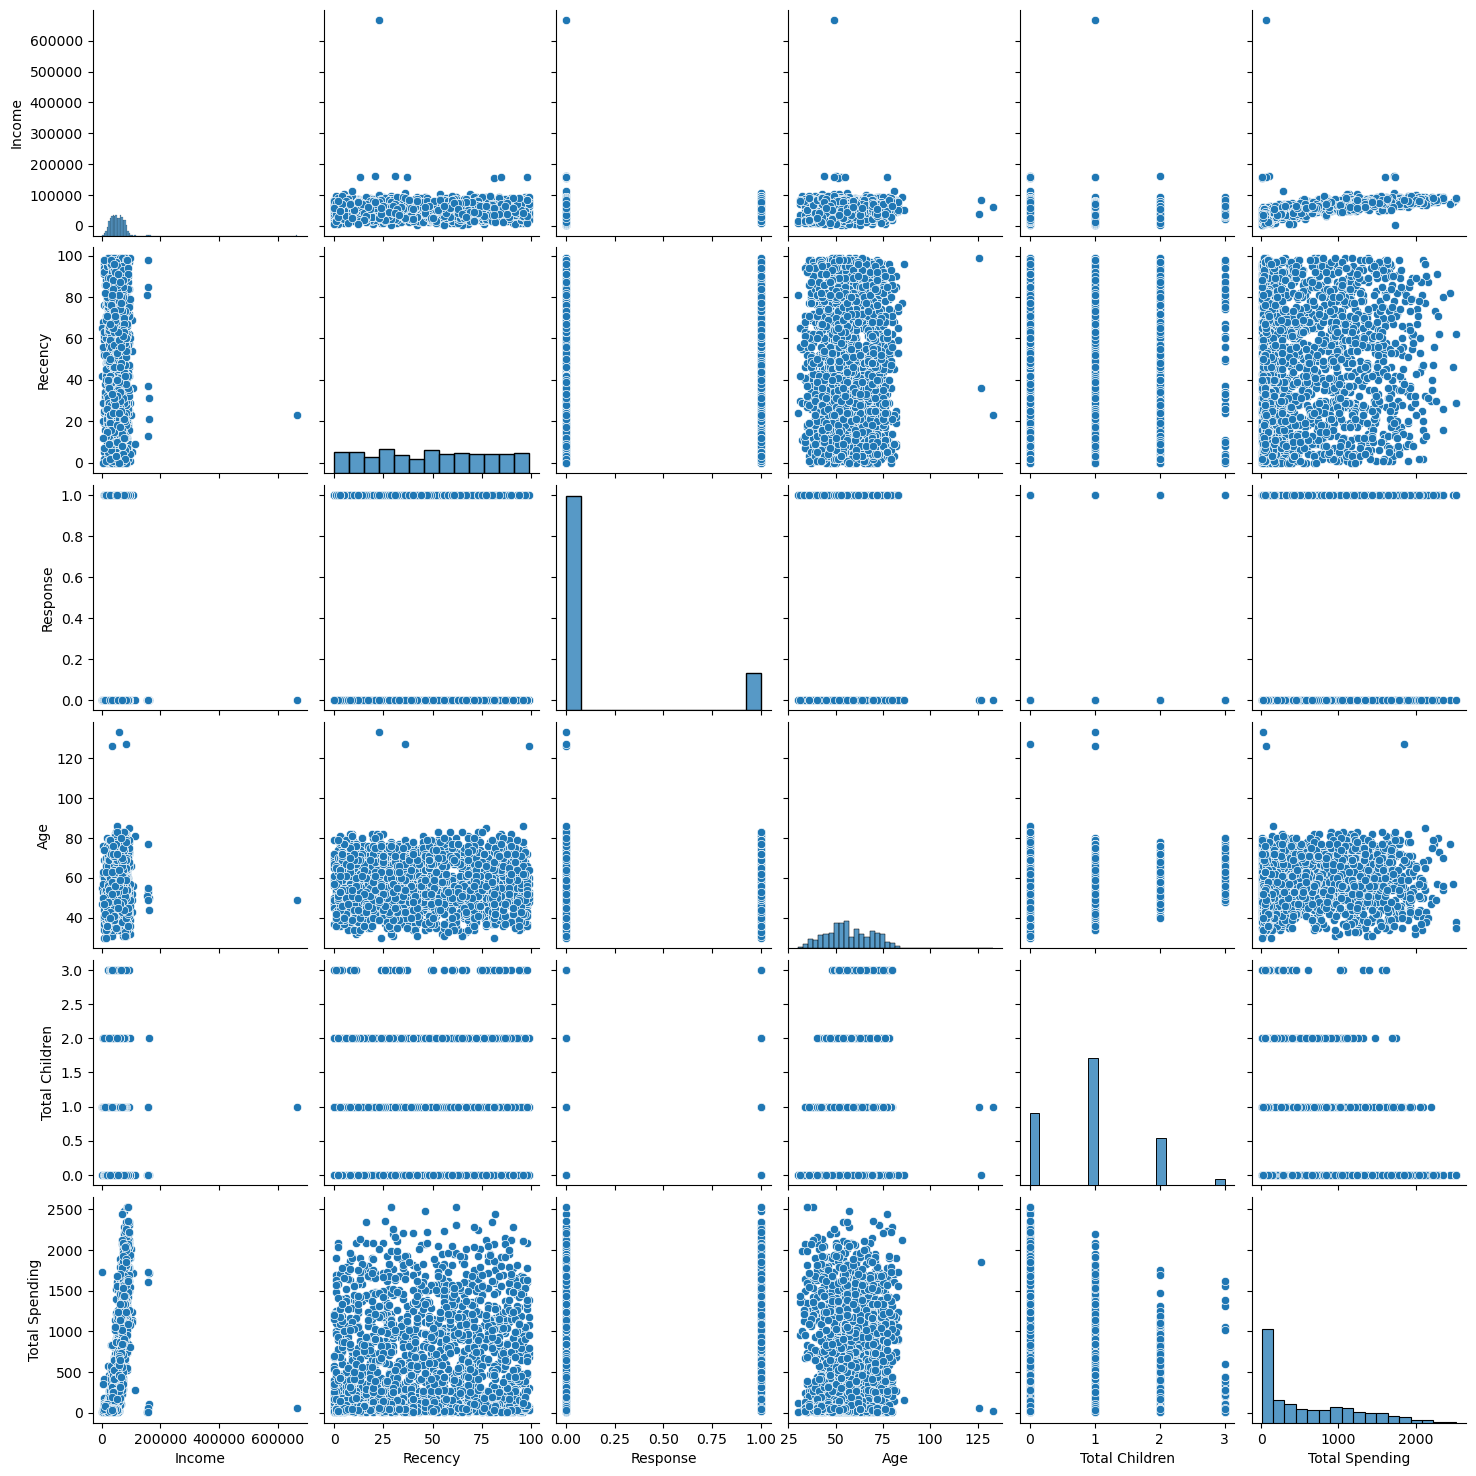

In [96]:
cols=["Income","Recency","Response","Age","Total Children","Total Spending"]


#relative pairplots of some features
plt.figure(figsize=(9,6))
sns.pairplot(X[cols])

plt.show()



In [97]:
# Remove outlier 

X=X[(X["Age"]<100)]
X=X[(X["Income"]<600000)]

In [98]:
print(len(X))

2236


# Heatmap

<Axes: >

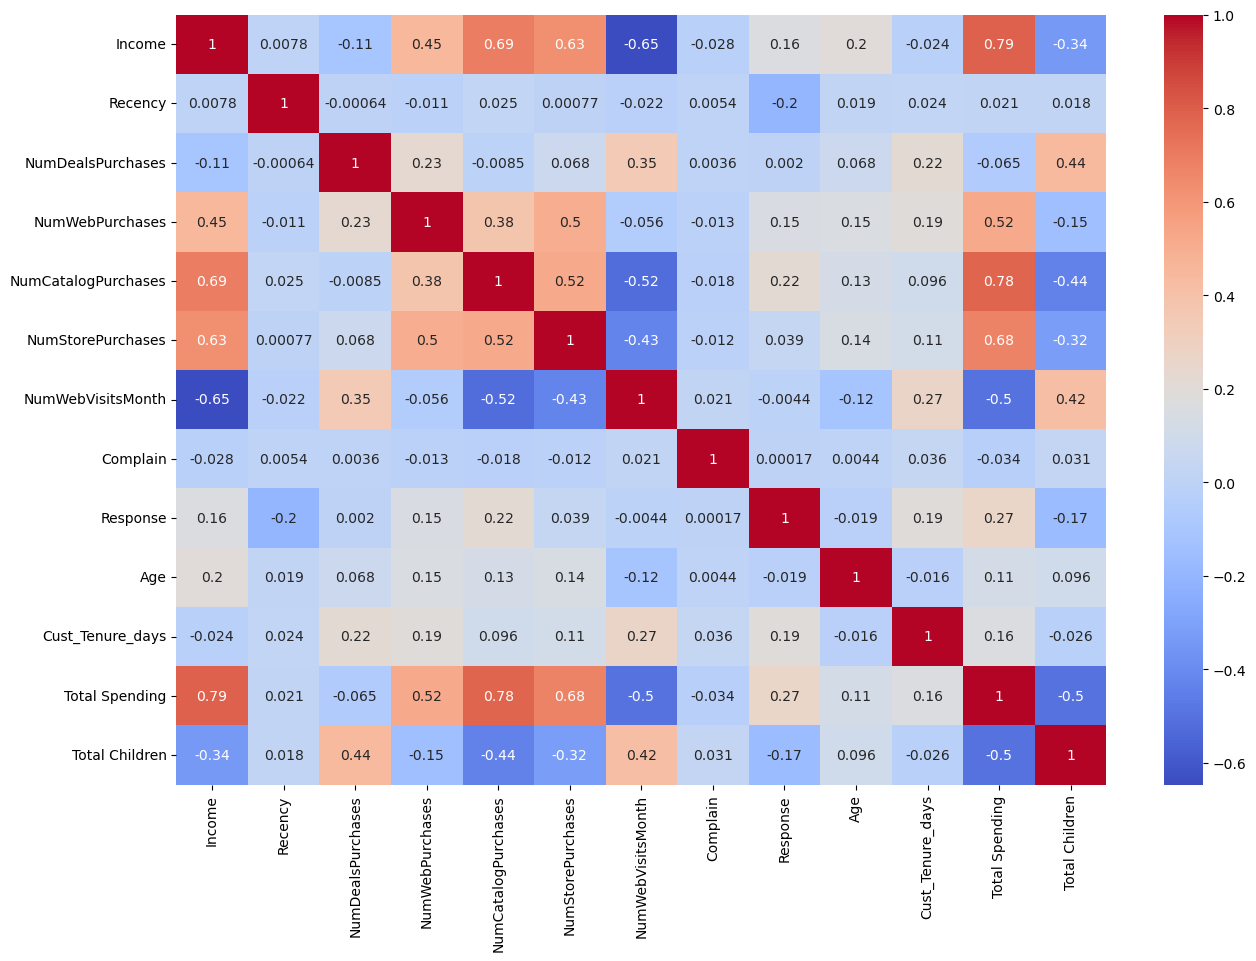

In [99]:
# Correlation heatmap

corr_matrix=X.corr(numeric_only=True)


plt.figure(figsize=(15,10))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm"
)

# Encoding 



In [100]:
from sklearn.preprocessing import OneHotEncoder

In [101]:
ohe =OneHotEncoder(sparse_output=False)

encoded=ohe.fit_transform(X[["Education","Living with"]])


In [102]:
encode_df=pd.DataFrame(encoded,columns=ohe.get_feature_names_out(["Education","Living with"]),index=X.index)


In [103]:
X=pd.concat([X.drop(columns=["Education","Living with"]),encode_df],axis=1)

In [104]:
X.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Cust_Tenure_days,Total Spending,Total Children,Education_Graduated,Education_PostGraduated,Education_UnderGraduated,Living with_Alone,Living with_Partner
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,0.0,1.0,0.0
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,0.0,1.0,0.0
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,1.0,0.0,0.0,0.0,1.0
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,1.0,0.0,0.0,0.0,1.0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,1.0,0.0,0.0,1.0


# Scaling

In [105]:
from sklearn.preprocessing import StandardScaler

In [106]:
scaler=StandardScaler()

X_scaled=scaler.fit_transform(X)

In [107]:
X_scaled

array([[ 0.28894655,  0.30685572,  0.34873831, ..., -0.35877969,
         1.3476353 , -1.3476353 ],
       [-0.262003  , -0.38397129, -0.16869955, ..., -0.35877969,
         1.3476353 , -1.3476353 ],
       [ 0.91842301, -0.7984675 , -0.68613742, ..., -0.35877969,
        -0.74204052,  0.74204052],
       ...,
       [ 0.234898  ,  1.44672029, -0.68613742, ..., -0.35877969,
         1.3476353 , -1.3476353 ],
       [ 0.80780332, -1.42021181, -0.16869955, ..., -0.35877969,
        -0.74204052,  0.74204052],
       [ 0.04280841, -0.31488859,  0.34873831, ..., -0.35877969,
        -0.74204052,  0.74204052]])

# Visualization

In [108]:
# PCA

#2D
from sklearn.decomposition import PCA

pca=PCA(n_components=2)

Xpca=pca.fit_transform(X_scaled)

print(pca.explained_variance_ratio_)


[0.23163158 0.11385454]


<Axes: >

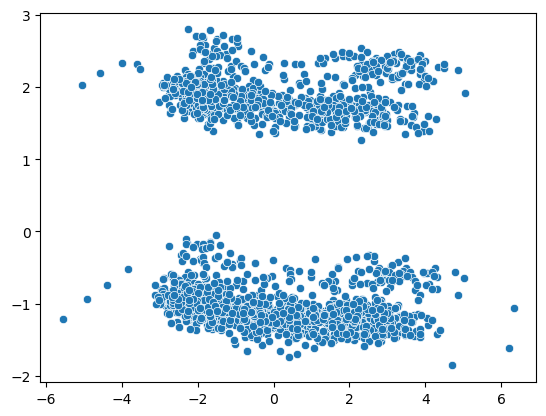

In [109]:
Xpca.shape

sns.scatterplot(x=Xpca[:,0],y=Xpca[:,1])

In [110]:
#3D

pca1=PCA(n_components=3)

X_pca=pca1.fit_transform(X_scaled)

print(pca1.explained_variance_ratio_)

[0.23163158 0.11385454 0.10405815]


Text(0.5, 0.92, '3D projection')

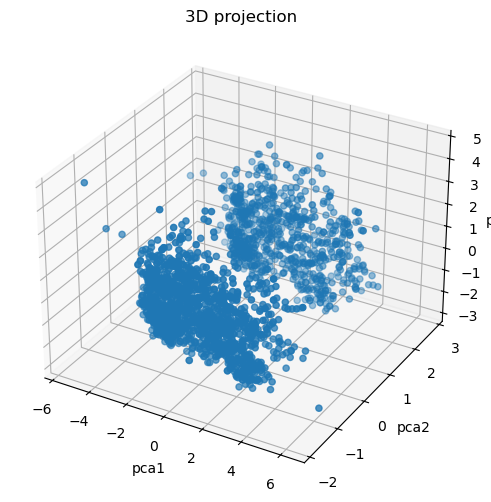

In [111]:
# 3D Visualization

fig=plt.figure(figsize=(9,6))

ax=fig.add_subplot(111, projection="3d")

ax.scatter(X_pca[:,0],X_pca[:,1],X_pca[:,2])

ax.set_xlabel("pca1")
ax.set_ylabel("pca2")
ax.set_zlabel("pca3")
ax.set_title("3D projection")

# Analyze K Value

## 1.Elbow Method

In [112]:
pip install kneed

Note: you may need to restart the kernel to use updated packages.


In [113]:
from sklearn.cluster import KMeans
from kneed import KneeLocator

In [114]:
wcss=[]
for k in range(1,11):
    model=KMeans(n_clusters=k,random_state=42)
    model.fit_predict(X_pca)
    wcss.append(model.inertia_)
    

In [115]:
wcss

[18093.257793324527,
 10760.843401758219,
 8830.288717243031,
 6650.969417658859,
 5006.161168001188,
 4396.308699108112,
 3857.633064427588,
 3207.0576242216985,
 3025.2232554326188,
 2651.442989106175]

In [116]:
knee=KneeLocator(range(1,11),wcss,curve="convex",direction="decreasing")
optimal_k=knee.elbow

print("Best K:",optimal_k)

Best K: 4


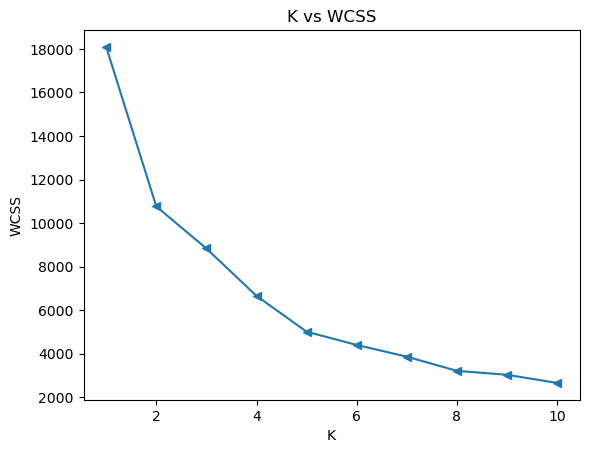

In [117]:
#plt

plt.plot(range(1,11),wcss,marker="<")

plt.xlabel("K")
plt.ylabel("WCSS")
plt.title("K vs WCSS")

plt.show()

## 2.Silhouette Score

In [118]:
from sklearn.metrics import silhouette_score

scores=[]

for k in range(2,11):
    model=KMeans(n_clusters=k,random_state=42)
    label=model.fit_predict(X_pca)
    score=silhouette_score(X_pca,label)

    scores.append(score)

Text(0.5, 0, 'k vs Silhouette score')

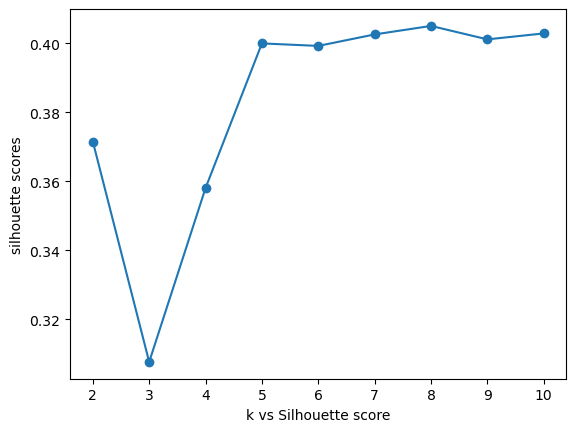

In [119]:
plt.plot(range(2,11),scores,marker="o")
plt.xlabel("K")
plt.ylabel("silhouette scores")
plt.xlabel("k vs Silhouette score")

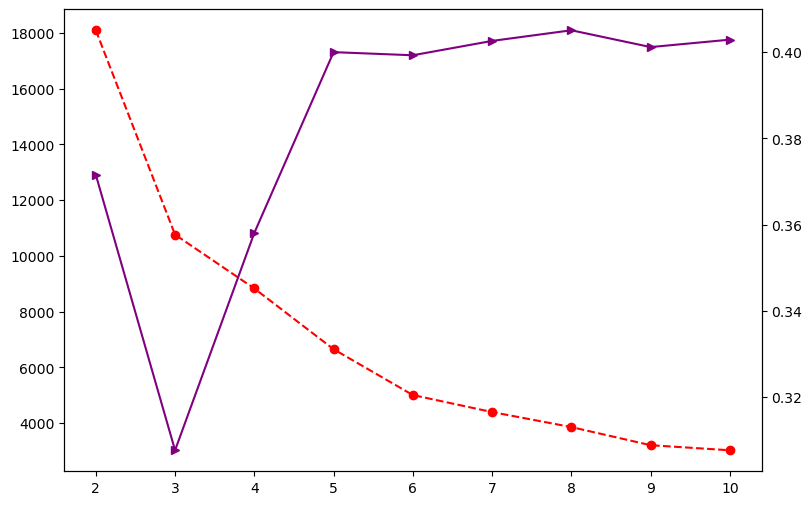

In [120]:
# combined plot

fig,ax=plt.subplots(figsize=(9,6))

k=range(2,11)

ax.plot(range(2,11),wcss[:len(k)],marker="o",color="red",linestyle="--")
ax1=ax.twinx()
ax1.plot(range(2,11),scores[:len(k)],marker=">",color="purple")



# Clustering

In [121]:
# KMeans

kmeans=KMeans(n_clusters=4,random_state=42)

labels=kmeans.fit_predict(X_pca)

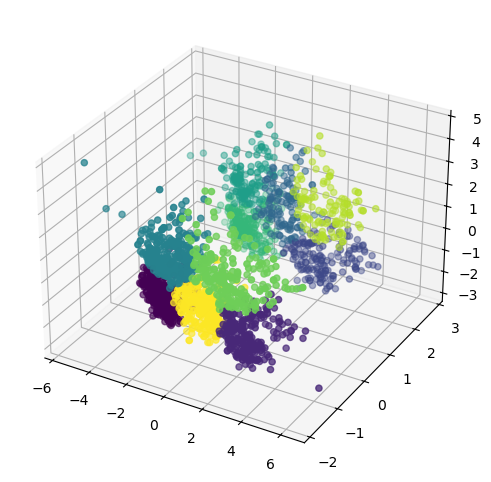

In [122]:
fig=plt.figure(figsize=(9,6))

ax=fig.add_subplot(111,projection="3d")

ax.scatter(X_pca[:,0],X_pca[:,1],X_pca[:,2],c=label)

In [123]:
# Agglomerative Clustering

from sklearn.cluster import AgglomerativeClustering


AC=AgglomerativeClustering(n_clusters=4,linkage="ward")

label=AC.fit_predict(X_pca)

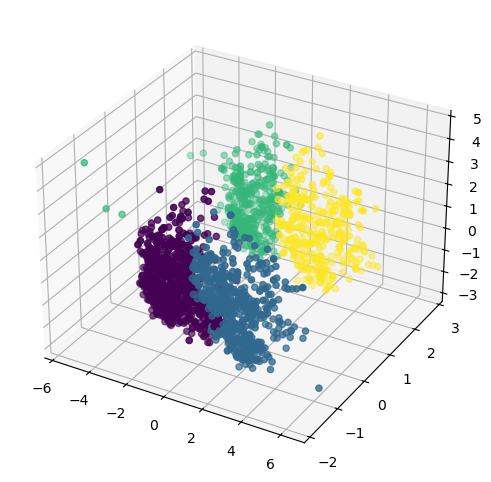

In [124]:
fig=plt.figure(figsize=(9,6))

ax=fig.add_subplot(111,projection="3d")

ax.scatter(X_pca[:,0],X_pca[:,1],X_pca[:,2],c=label)

# Characterization of cluster 

In [125]:
X["cluster"]=label

In [126]:
X.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Cust_Tenure_days,Total Spending,Total Children,Education_Graduated,Education_PostGraduated,Education_UnderGraduated,Living with_Alone,Living with_Partner,cluster
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,0.0,1.0,0.0,3
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,0.0,1.0,0.0,2
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,1.0,0.0,0.0,0.0,1.0,1
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,1.0,0.0,0.0,0.0,1.0,0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,1.0,0.0,0.0,1.0,0


<Axes: xlabel='cluster', ylabel='count'>

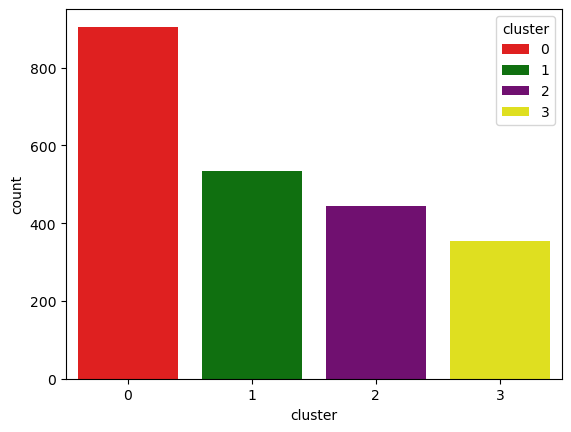

In [127]:
#countplot
pal=["red","green","purple","yellow"]
sns.countplot(x=X["cluster"],palette=pal,hue=X["cluster"])

<Axes: xlabel='Total Spending', ylabel='Income'>

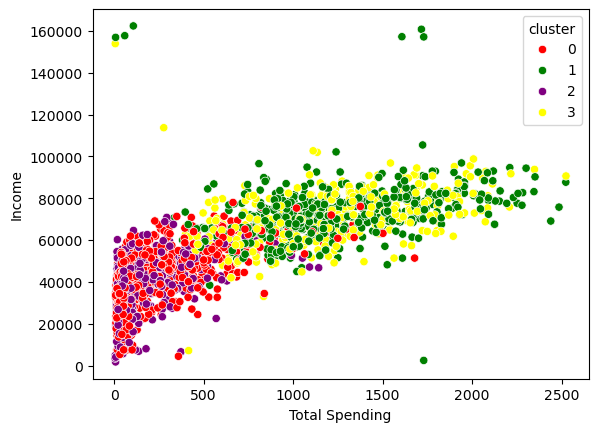

In [129]:
#Income and spending patterns


sns.scatterplot(x=X["Total Spending"],y=X["Income"],hue=X["cluster"],palette=pal)

In [130]:
# summary for all the clusters

cluster_summary=X.groupby("cluster").mean()
print(cluster_summary)

               Income    Recency  NumDealsPurchases  NumWebPurchases  \
cluster                                                                
0        39680.580110  48.914917           2.594475         3.153591   
1        72808.445693  49.202247           1.958801         5.687266   
2        36960.143018  48.319820           2.594595         2.713964   
3        70722.681303  50.504249           1.855524         5.790368   

         NumCatalogPurchases  NumStorePurchases  NumWebVisitsMonth  Complain  \
cluster                                                                        
0                   0.969061           4.143646           6.307182  0.011050   
1                   5.498127           8.659176           3.580524  0.005618   
2                   0.837838           3.623874           6.659910  0.011261   
3                   5.014164           8.430595           3.728045  0.005666   

         Response        Age  Cust_Tenure_days  Total Spending  \
cluster             